# Promising HOG Pipeline Combinations (Full PlantVillage)

This notebook evaluates 3 selected high-potential combinations on the **full PlantVillage dataset (all classes)** using:
- Preprocessing: `gaussian`
- Segmentation: `otsu`
- Edge: `canny`
- Corner: `shi_tomasi`
- Feature: `hog`

Morphology combinations tested:
1. `opening` only
2. `erosion` then `dilation`
3. `opening` then `closing`

## Imports

In [1]:
from pathlib import Path

import cv2
import numpy as np

from classifiers import train_and_evaluate
from features import detect_corners, detect_edges, extract_hog
from processing import apply_morphology, apply_preprocessing, segment_leaf

## Configuracion y helpers

In [8]:
dataset_root = Path("PlantVillage")
if not dataset_root.exists():
    raise FileNotFoundError(f"Dataset root not found: {dataset_root}")

fixed_preprocess = "gaussian"
fixed_segmentation = "otsu"
fixed_edge = "canny"
fixed_corner = "shi_tomasi"
fixed_feature = "hog"

morphology_configs = [
    ("opening", None, "opening only"),
    ("erosion", "dilation", "erosion then dilation"),
    ("opening", "closing", "opening then closing"),
]

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def list_class_dirs(root: Path) -> list[Path]:
    class_dirs = []
    for candidate in sorted(root.iterdir()):
        if not candidate.is_dir():
            continue
        if candidate.name == "PlantVillage":
            continue
        if "tomato" not in candidate.name.lower():
            continue
        has_images = any(
            image_path.is_file() and image_path.suffix.lower() in image_extensions
            for image_path in candidate.rglob("*")
        )
        if has_images:
            class_dirs.append(candidate)
    return class_dirs


def list_images(class_dir: Path) -> list[Path]:
    images = [
        path for path in class_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in image_extensions
    ]
    return sorted(images)


def process_for_hog(
    grayscale: np.ndarray,
    preprocess: str,
    segmentation: str,
    morph_first: str | None,
    morph_second: str | None,
    edge: str,
    corner: str,
) -> np.ndarray:
    working = apply_preprocessing(grayscale, filter_type=preprocess)

    mask = segment_leaf(working, method=segmentation)
    if morph_first is not None:
        mask = apply_morphology(mask, operation=morph_first)
    if morph_second is not None:
        mask = apply_morphology(mask, operation=morph_second)

    working = cv2.bitwise_and(working, working, mask=mask)
    working = detect_edges(working, method=edge)
    corners_bgr = detect_corners(working, method=corner)
    final_gray = cv2.cvtColor(corners_bgr, cv2.COLOR_BGR2GRAY)

    return final_gray


def build_dataset_for_combo(
    class_dirs: list[Path],
    morph_first: str | None,
    morph_second: str | None,
    sample_fraction: float = 1.0,
    max_per_class: int | None = None,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    if not (0 < sample_fraction <= 1.0):
        raise ValueError("sample_fraction must be in (0, 1].")

    rng = np.random.default_rng(seed)
    total_images = 0

    # Build binary labels: healthy vs not_healthy
    healthy_pairs = []
    not_healthy_pairs = []

    for class_dir in class_dirs:
        image_paths = list_images(class_dir)
        if sample_fraction < 1.0:
            k = max(1, int(np.floor(len(image_paths) * sample_fraction)))
            image_paths = list(rng.choice(image_paths, size=min(k, len(image_paths)), replace=False))
        if max_per_class is not None:
            image_paths = image_paths[: max_per_class]

        label = "healthy" if "healthy" in class_dir.name.lower() else "not_healthy"
        print(f"Class: {class_dir.name} | images: {len(image_paths)} | label: {label}")

        for image_path in image_paths:
            if label == "healthy":
                healthy_pairs.append((image_path, class_dir.name))
            else:
                not_healthy_pairs.append((image_path, class_dir.name))

    if len(healthy_pairs) == 0 or len(not_healthy_pairs) == 0:
        raise ValueError("Need both healthy and not_healthy samples to build a balanced dataset.")

    # Balance classes using the smallest class size
    rng.shuffle(healthy_pairs)
    rng.shuffle(not_healthy_pairs)
    target_size = min(len(healthy_pairs), len(not_healthy_pairs))
    healthy_pairs = healthy_pairs[:target_size]
    not_healthy_pairs = not_healthy_pairs[:target_size]

    # Process images for balanced dataset
    X_rows = []
    y_rows = []
    for image_path, class_name in healthy_pairs + not_healthy_pairs:
        image_bgr = cv2.imread(str(image_path))
        if image_bgr is None:
            continue

        grayscale = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
        processed = process_for_hog(
            grayscale=grayscale,
            preprocess=fixed_preprocess,
            segmentation=fixed_segmentation,
            morph_first=morph_first,
            morph_second=morph_second,
            edge=fixed_edge,
            corner=fixed_corner,
        )

        hog_features, _ = extract_hog(processed)
        X_rows.append(hog_features.astype(np.float32))
        y_rows.append("healthy" if "healthy" in class_name.lower() else "not_healthy")
        total_images += 1

        if total_images % 500 == 0:
            print(f"  Processed {total_images} images so far...")

    if len(X_rows) < 5:
        raise ValueError("Need at least 5 valid samples for 5-fold CV.")

    X = np.vstack(X_rows).astype(np.float32)
    y = np.array(y_rows)
    return X, y


def build_dataset_for_combo_multiclass(
    class_dirs: list[Path],
    morph_first: str | None,
    morph_second: str | None,
    sample_fraction: float = 1.0,
    max_per_class: int | None = None,
    seed: int = 42,
    balance: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    if not (0 < sample_fraction <= 1.0):
        raise ValueError("sample_fraction must be in (0, 1].")

    rng = np.random.default_rng(seed)
    class_to_paths: dict[str, list[Path]] = {}

    for class_dir in class_dirs:
        image_paths = list_images(class_dir)
        if sample_fraction < 1.0:
            k = max(1, int(np.floor(len(image_paths) * sample_fraction)))
            image_paths = list(rng.choice(image_paths, size=min(k, len(image_paths)), replace=False))
        if max_per_class is not None:
            image_paths = image_paths[: max_per_class]

        class_to_paths[class_dir.name] = image_paths

    if balance:
        min_count = min(len(paths) for paths in class_to_paths.values())
        class_to_paths = {name: paths[:min_count] for name, paths in class_to_paths.items()}

    X_rows = []
    y_rows = []
    total_images = 0

    for class_name, image_paths in class_to_paths.items():
        print(f"Class: {class_name} | images: {len(image_paths)}")
        for image_path in image_paths:
            image_bgr = cv2.imread(str(image_path))
            if image_bgr is None:
                continue

            grayscale = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
            processed = process_for_hog(
                grayscale=grayscale,
                preprocess=fixed_preprocess,
                segmentation=fixed_segmentation,
                morph_first=morph_first,
                morph_second=morph_second,
                edge=fixed_edge,
                corner=fixed_corner,
            )

            hog_features, _ = extract_hog(processed)
            X_rows.append(hog_features.astype(np.float32))
            y_rows.append(class_name)
            total_images += 1

            if total_images % 500 == 0:
                print(f"  Processed {total_images} images so far...")

    if len(X_rows) < 5:
        raise ValueError("Need at least 5 valid samples for 5-fold CV.")

    X = np.vstack(X_rows).astype(np.float32)
    y = np.array(y_rows)
    return X, y

## Listado de clases

In [3]:
class_directories = list_class_dirs(dataset_root)
class_directories = [d for d in class_directories if d != "PlantVillage"]
if not class_directories:
    raise ValueError(f"No class folders with images found in {dataset_root}.")

print(f"Found {len(class_directories)} classes.")
for class_dir in class_directories:
    print(f"- {class_dir.name}")

Found 10 classes.
- Tomato__Target_Spot
- Tomato__Tomato_mosaic_virus
- Tomato__Tomato_YellowLeaf__Curl_Virus
- Tomato_Bacterial_spot
- Tomato_Early_blight
- Tomato_healthy
- Tomato_Late_blight
- Tomato_Leaf_Mold
- Tomato_Septoria_leaf_spot
- Tomato_Spider_mites_Two_spotted_spider_mite


## Evaluacion de combinaciones


Evaluating combo: opening only
Class: Tomato__Target_Spot | images: 702 | label: not_healthy
Class: Tomato__Tomato_mosaic_virus | images: 186 | label: not_healthy
Class: Tomato__Tomato_YellowLeaf__Curl_Virus | images: 1604 | label: not_healthy
Class: Tomato_Bacterial_spot | images: 1063 | label: not_healthy
Class: Tomato_Early_blight | images: 500 | label: not_healthy
Class: Tomato_healthy | images: 795 | label: healthy
Class: Tomato_Late_blight | images: 954 | label: not_healthy
Class: Tomato_Leaf_Mold | images: 476 | label: not_healthy
Class: Tomato_Septoria_leaf_spot | images: 885 | label: not_healthy
Class: Tomato_Spider_mites_Two_spotted_spider_mite | images: 838 | label: not_healthy
  Processed 500 images so far...
  Processed 1000 images so far...
  Processed 1500 images so far...
Feature matrix shape: (1590, 34596)
Labels shape: (1590,)
Model: kNN
  Accuracy: 0.7950
  Weighted F1-score: 0.7910
Model: SVM
  Accuracy: 0.8434
  Weighted F1-score: 0.8429
Model: RandomForest
  Accu

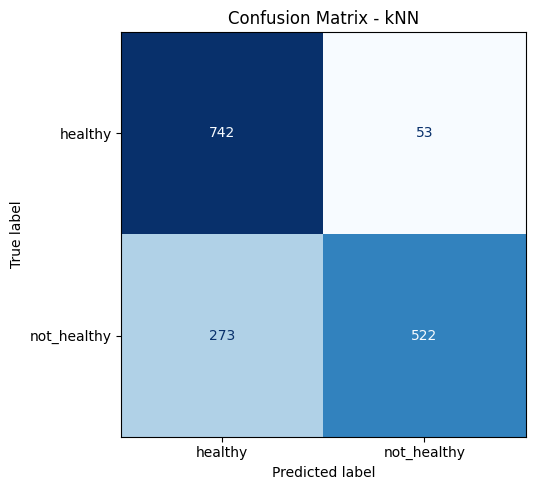

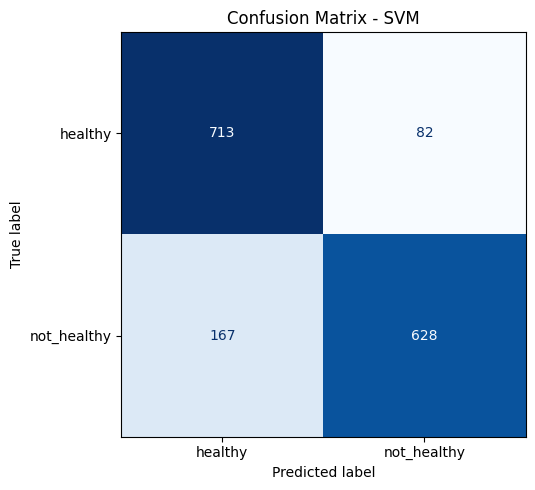

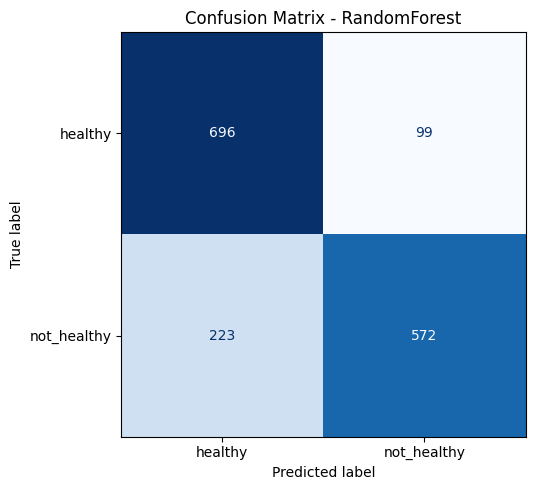

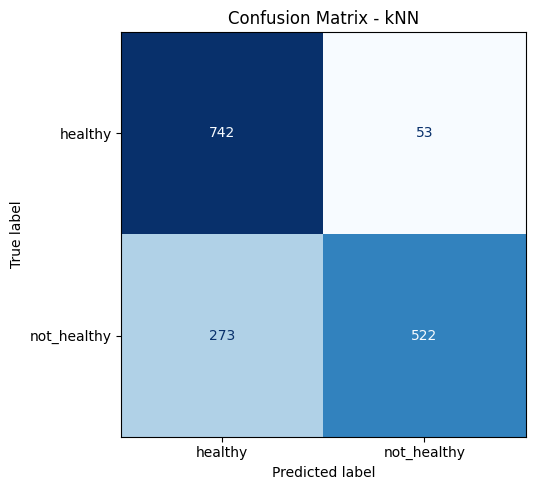

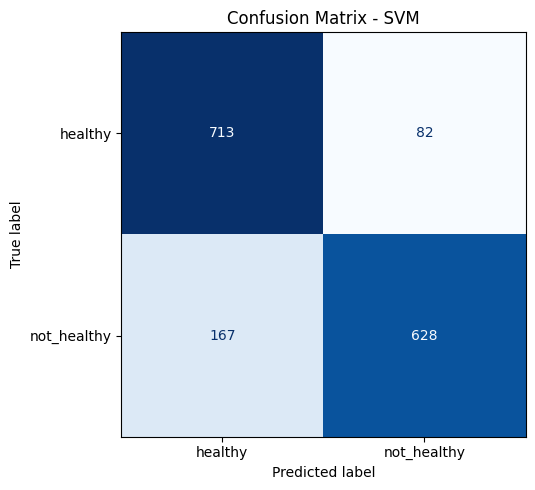

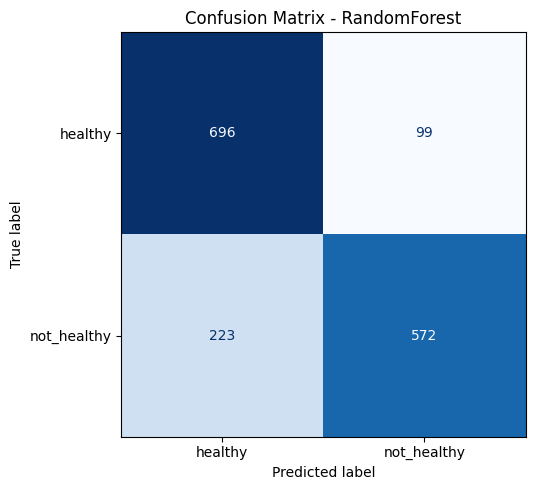

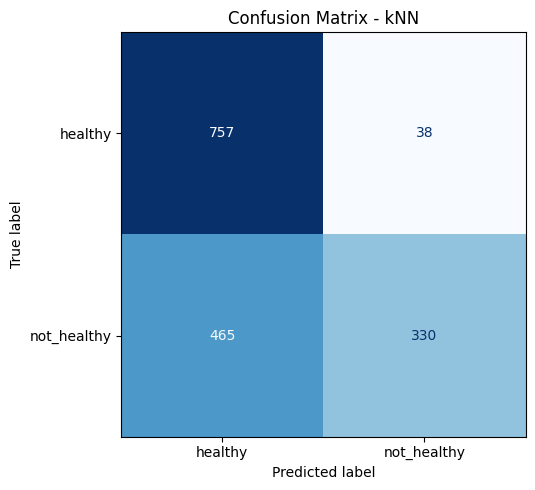

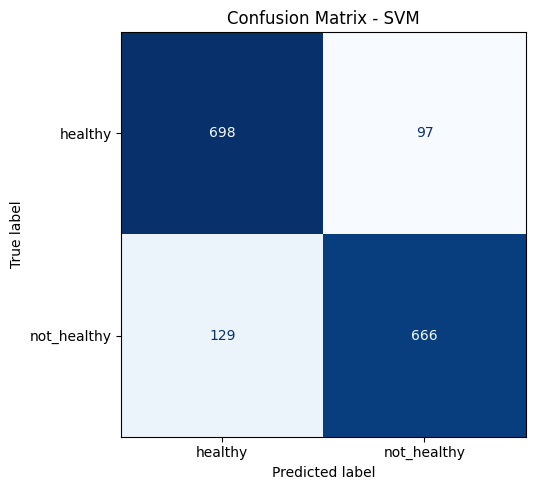

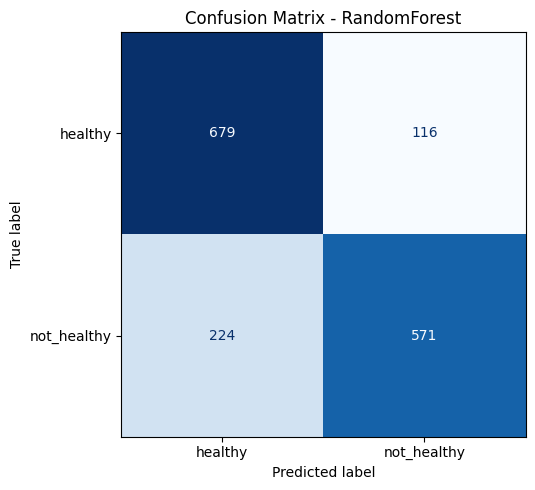

In [5]:
import gc

all_results = []

# Reduce memory usage by sampling a fraction of each class
sample_fraction = 0.5  # use 20% per class for quick experiments
max_per_class = None   # set an int (e.g., 200) to hard-cap per class

for morph_first, morph_second, combo_name in morphology_configs:
    print("\n" + "=" * 90)
    print(f"Evaluating combo: {combo_name}")
    print("=" * 90)

    X, y = build_dataset_for_combo(
        class_directories,
        morph_first,
        morph_second,
        sample_fraction=sample_fraction,
        max_per_class=max_per_class,
        seed=42,
    )
    print(f"Feature matrix shape: {X.shape}")
    print(f"Labels shape: {y.shape}")

    combo_metrics = train_and_evaluate(X, y)

    for model_name, metrics in combo_metrics.items():
        print(f"Model: {model_name}")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        print(f"  Weighted F1-score: {metrics['f1_score']:.4f}")

        all_results.append(
            {
                "combo": combo_name,
                "morph_first": morph_first,
                "morph_second": morph_second,
                "model": model_name,
                "accuracy": float(metrics["accuracy"]),
                "weighted_f1": float(metrics["f1_score"]),
                "confusion_matrix": metrics["confusion_matrix"],
                "confusion_matrix_figure": metrics["confusion_matrix_figure"],
            }
        )

    # Free memory before next combo
    del X, y, combo_metrics
    gc.collect()

## Ranking final

In [6]:
print("\nFinal ranking by weighted F1-score:")
sorted_results = sorted(all_results, key=lambda result: result["weighted_f1"], reverse=True)
for rank, result in enumerate(sorted_results, start=1):
    print(
        f"{rank:02d}. combo={result['combo']} | model={result['model']} | "
        f"acc={result['accuracy']:.4f} | f1={result['weighted_f1']:.4f}"
    )


Final ranking by weighted F1-score:
01. combo=opening then closing | model=SVM | acc=0.8579 | f1=0.8578
02. combo=opening only | model=SVM | acc=0.8434 | f1=0.8429
03. combo=erosion then dilation | model=SVM | acc=0.8434 | f1=0.8429
04. combo=opening only | model=RandomForest | acc=0.7975 | f1=0.7962
05. combo=erosion then dilation | model=RandomForest | acc=0.7975 | f1=0.7962
06. combo=opening only | model=kNN | acc=0.7950 | f1=0.7910
07. combo=erosion then dilation | model=kNN | acc=0.7950 | f1=0.7910
08. combo=opening then closing | model=RandomForest | acc=0.7862 | f1=0.7852
09. combo=opening then closing | model=kNN | acc=0.6836 | f1=0.6591


## Evaluacion multiclase (tomato)


Evaluating combo (multiclass): opening only
Class: Tomato__Target_Spot | images: 186
Class: Tomato__Tomato_mosaic_virus | images: 186
Class: Tomato__Tomato_YellowLeaf__Curl_Virus | images: 186
  Processed 500 images so far...
Class: Tomato_Bacterial_spot | images: 186
Class: Tomato_Early_blight | images: 186
Class: Tomato_healthy | images: 186
  Processed 1000 images so far...
Class: Tomato_Late_blight | images: 186
Class: Tomato_Leaf_Mold | images: 186
Class: Tomato_Septoria_leaf_spot | images: 186
  Processed 1500 images so far...
Class: Tomato_Spider_mites_Two_spotted_spider_mite | images: 186
Feature matrix shape: (1860, 34596)
Labels shape: (1860,)
Model: kNN
  Accuracy: 0.2629
  Weighted F1-score: 0.2496
Model: SVM
  Accuracy: 0.3941
  Weighted F1-score: 0.3784
Model: RandomForest
  Accuracy: 0.3392
  Weighted F1-score: 0.3146

Evaluating combo (multiclass): erosion then dilation
Class: Tomato__Target_Spot | images: 186
Class: Tomato__Tomato_mosaic_virus | images: 186
Class: Tom

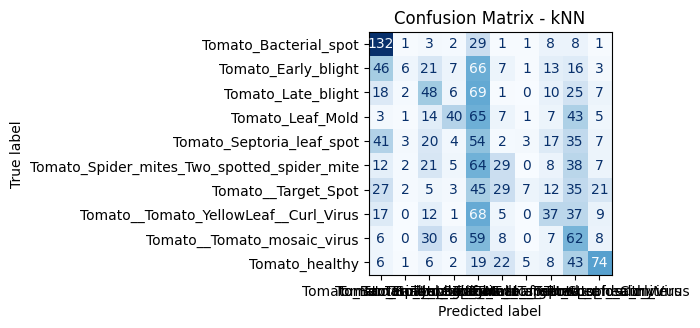

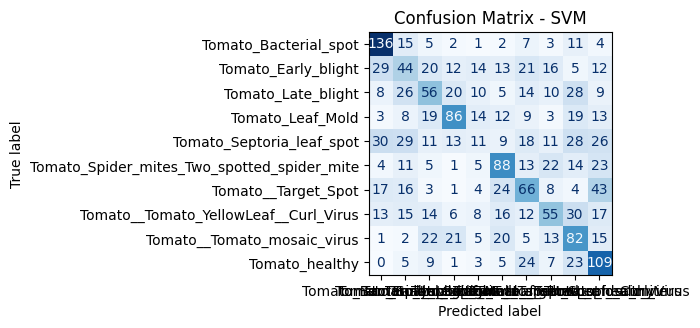

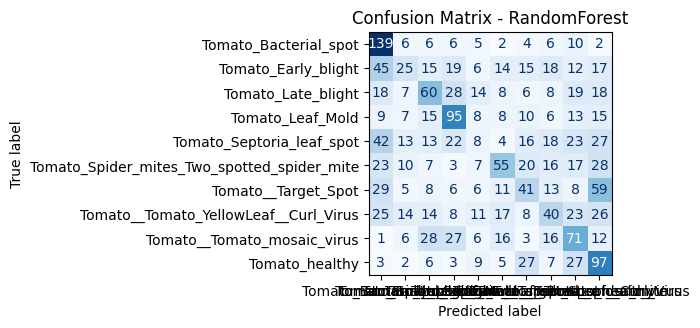

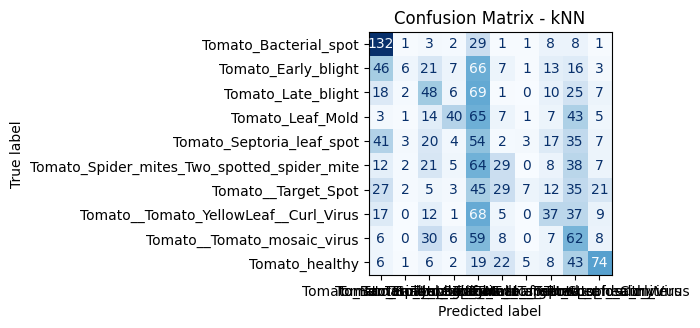

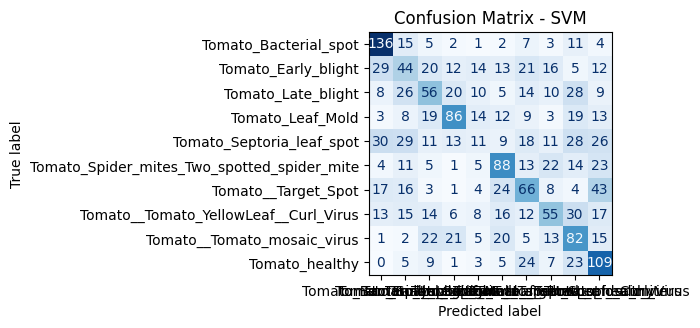

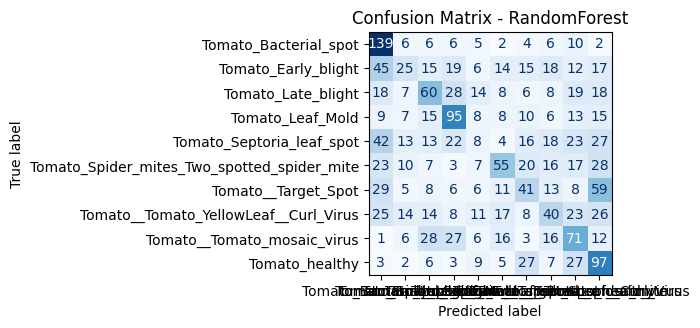

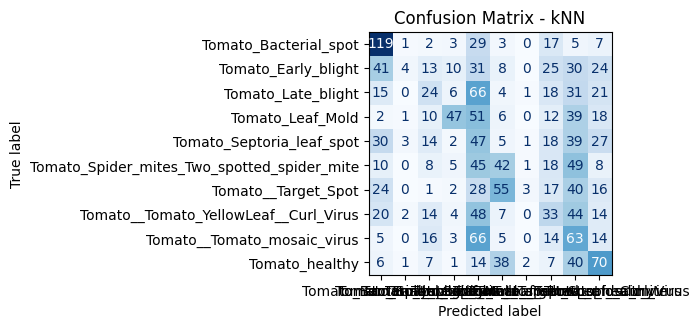

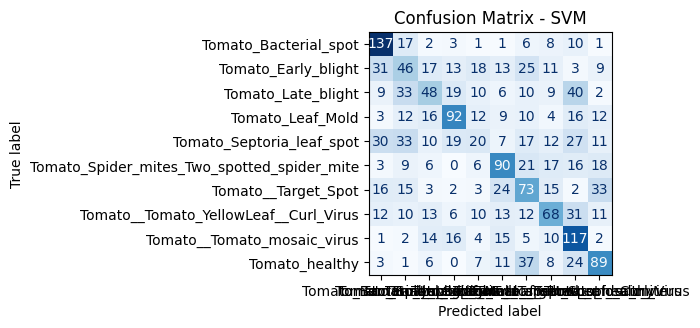

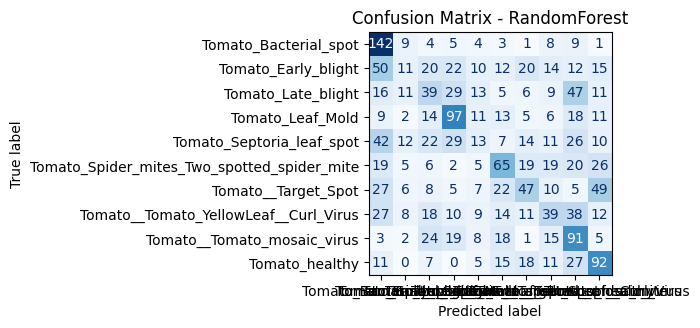

In [11]:
import gc

all_results_multiclass = []

# Reduce memory usage by sampling a fraction of each class
sample_fraction_multiclass = 0.5
max_per_class_multiclass = None
balance_multiclass = True

for morph_first, morph_second, combo_name in morphology_configs:
    print("\n" + "=" * 90)
    print(f"Evaluating combo (multiclass): {combo_name}")
    print("=" * 90)

    X, y = build_dataset_for_combo_multiclass(
        class_directories,
        morph_first,
        morph_second,
        sample_fraction=sample_fraction_multiclass,
        max_per_class=max_per_class_multiclass,
        seed=42,
        balance=balance_multiclass,
    )
    print(f"Feature matrix shape: {X.shape}")
    print(f"Labels shape: {y.shape}")

    combo_metrics = train_and_evaluate(X, y)

    for model_name, metrics in combo_metrics.items():
        print(f"Model: {model_name}")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        print(f"  Weighted F1-score: {metrics['f1_score']:.4f}")

        all_results_multiclass.append(
            {
                "combo": combo_name,
                "morph_first": morph_first,
                "morph_second": morph_second,
                "model": model_name,
                "accuracy": float(metrics["accuracy"]),
                "weighted_f1": float(metrics["f1_score"]),
                "confusion_matrix": metrics["confusion_matrix"],
                "confusion_matrix_figure": metrics["confusion_matrix_figure"],
            }
        )

    # Free memory before next combo
    del X, y, combo_metrics
    gc.collect()

## Ranking final (multiclase)

In [12]:
print("\nFinal ranking by weighted F1-score (multiclass):")
sorted_results_multiclass = sorted(
    all_results_multiclass, key=lambda result: result["weighted_f1"], reverse=True
)
for rank, result in enumerate(sorted_results_multiclass, start=1):
    print(
        f"{rank:02d}. combo={result['combo']} | model={result['model']} | "
        f"acc={result['accuracy']:.4f} | f1={result['weighted_f1']:.4f}"
    )


Final ranking by weighted F1-score (multiclass):
01. combo=opening then closing | model=SVM | acc=0.4194 | f1=0.4054
02. combo=opening only | model=SVM | acc=0.3941 | f1=0.3784
03. combo=erosion then dilation | model=SVM | acc=0.3941 | f1=0.3784
04. combo=opening only | model=RandomForest | acc=0.3392 | f1=0.3146
05. combo=erosion then dilation | model=RandomForest | acc=0.3392 | f1=0.3146
06. combo=opening then closing | model=RandomForest | acc=0.3419 | f1=0.3127
07. combo=opening only | model=kNN | acc=0.2629 | f1=0.2496
08. combo=erosion then dilation | model=kNN | acc=0.2629 | f1=0.2496
09. combo=opening then closing | model=kNN | acc=0.2430 | f1=0.2240
